# # Cardiovascular Disease Risk Prediction — Notebook 3

## Model Optimization, Threshold Tuning & Deployment Pipeline

### Objective

This notebook converts the baseline ML pipeline from Notebook 2 into a
final, optimized, reproducible and deployment-ready cardiovascular
disease risk prediction system.

### Main Tasks

1. Hyperparameter optimization
2. Best model selection
3. Threshold optimization
4. Final model evaluation and metrics
5. Saved model artifact
6. Raw patient input → preprocessing → prediction pipeline
7. Prediction API contract
8. Plug-and-play prediction component

### Final Output

**Optimized Model + Optimized Threshold + Final Metrics
+ Saved Model Artifact + Risk Probability + Final Risk Prediction
+ API Contract**

The final system is designed for reproducible API/application integration.

## Final End-to-End ML Workflow

### Previous Work

**Notebook 1**
→ Outlier Removal + Data Cleaning
→ `cardio_final_cleaned.csv`

**Notebook 2**
→ Feature Engineering & Data Preparation
→ `age → age_years`
→ `height + weight → BMI`
→ Remove `id` and raw `age`
→ Stratified Train/Test Split
→ Baseline Models:
   - Logistic Regression
   - Random Forest
   - XGBoost

### Notebook 3 — Final ML Pipeline

Notebook 2 Model-Ready Data
        ↓
Hyperparameter Optimization
        ↓
Optimized Model Comparison
        ↓
Best Model Selection
        ↓
Out-of-Fold Probabilities
        ↓
Optimized Decision Threshold
        ↓
Final Model Retraining
        ↓
Untouched Test-Set Evaluation
        ↓
Final Metrics
        ↓
Saved Model Artifact + Threshold + Metadata
        ↓
Reusable Prediction Component
        ↓
Prediction API Contract

---

## Final Prediction Flow

**Raw Patient Input**
        ↓
**Preprocessing**
        ↓
**Selected Optimized Model**
        ↓
**Risk Probability**
        ↓
**Optimized Threshold**
        ↓
**Final Risk Prediction**
        ↓
**API / Plug-and-Play Integration**

### Final Goal

Build a complete, reproducible and deployment-ready ML pipeline that
takes raw patient input and produces the final cardiovascular risk
probability and risk prediction.

# Imports

In [2]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import json
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("All libraries imported successfully!")

All libraries imported successfully!


# Load Notebook 2 output

** Cleaned Dataset Injested from notebook2**

In [3]:
# ============================================================
# 2. LOAD MODEL-READY DATA FROM NOTEBOOK 2
# ============================================================

# Notebook 2 already created these processed datasets.
# We are NOT repeating data cleaning or feature engineering here.

TRAIN_FILE = "cardio_train_processed.csv"
TEST_FILE = "cardio_test_processed.csv"


def find_file(filename):
    """
    Search Kaggle input and working directories
    for the required Notebook 2 output file.
    """

    search_locations = [
        "/kaggle/input",
        "/kaggle/working"
    ]

    matches = []

    for location in search_locations:

        for root, dirs, files in os.walk(location):

            if filename in files:
                matches.append(
                    os.path.join(root, filename)
                )

    return matches


train_matches = find_file(TRAIN_FILE)
test_matches = find_file(TEST_FILE)


# # print("Training file:")
# for path in train_matches:
#     print( path)

# # print("\nTesting file:")
# for path in test_matches:
#     print( path)


if not train_matches or not test_matches:

    raise FileNotFoundError(
        """
        Notebook 2 processed datasets were not found.

        Please add the dataset containing:
        - cardio_train_processed.csv
        - cardio_test_processed.csv
        """
    )


TRAIN_PATH = train_matches[0]
TEST_PATH = test_matches[0]


train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)


print("\nTraining data shape:", train_df.shape)
print("Testing data shape :", test_df.shape)

print("\n Notebook 2 model-ready data loaded successfully.")


Training data shape: (49999, 13)
Testing data shape : (12500, 13)

 Notebook 2 model-ready data loaded successfully.


# Separate Features & Target

In [4]:
# ============================================================
# 3. SEPARATE FEATURES AND TARGET
# ============================================================

# Target variable
TARGET = "cardio"

# Separate input features and target
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]


# ------------------------------------------------------------
# Basic verification
# ------------------------------------------------------------

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)


print("\nTarget distribution — Training:")
print(y_train.value_counts())

print("\nTarget distribution — Testing:")
print(y_test.value_counts())


print("\nModel features:")
for i, feature in enumerate(X_train.columns, start=1):
    print(f"{i}. {feature}")

X_train shape: (49999, 12)
y_train shape: (49999,)

X_test shape : (12500, 12)
y_test shape : (12500,)

Target distribution — Training:
cardio
0    25305
1    24694
Name: count, dtype: int64

Target distribution — Testing:
cardio
0    6326
1    6174
Name: count, dtype: int64

Model features:
1. gender
2. height
3. weight
4. ap_hi
5. ap_lo
6. cholesterol
7. gluc
8. smoke
9. alco
10. active
11. age_years
12. BMI


# Data Integrity Check

In [5]:
# ============================================================
# 4. DATA INTEGRITY CHECK
# ============================================================

print("Missing values in training data:")
print(X_train.isnull().sum().sum())

print("\nMissing values in testing data:")
print(X_test.isnull().sum().sum())

print("\nDuplicate rows in training features:", X_train.duplicated().sum())
print("Duplicate rows in testing features :", X_test.duplicated().sum())

print("\nTarget classes:")
print(sorted(y_train.unique()))

print("\n Data integrity check completed.")

Missing values in training data:
0

Missing values in testing data:
0

Duplicate rows in training features: 12332
Duplicate rows in testing features : 1534

Target classes:
[np.int64(0), np.int64(1)]

 Data integrity check completed.


# Cross-Validation Setup

In [6]:
# ============================================================
# 5. CROSS-VALIDATION SETUP
# ============================================================

# Stratified K-Fold keeps the class distribution balanced
# across all validation folds.

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:")
print("5-Fold Stratified Cross-Validation")
print("Random State:", 42)

Cross-validation strategy:
5-Fold Stratified Cross-Validation
Random State: 42


#  Models + Hyperparameter Grids

In [7]:
# ============================================================
# 6. DEFINE MODELS AND HYPERPARAMETER SEARCH SPACES
# ============================================================

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

lr_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"]
}


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_params = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}


print("✓ Hyperparameter search spaces defined.")
print("✓ Models: Logistic Regression, Random Forest, XGBoost")

✓ Hyperparameter search spaces defined.
✓ Models: Logistic Regression, Random Forest, XGBoost


# Hyperparameter Optimization

In [8]:
# ============================================================
# 7. HYPERPARAMETER OPTIMIZATION
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

searches = {}

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

print("=" * 60)
print("Optimizing Logistic Regression...")
print("=" * 60)

lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions={
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["liblinear", "lbfgs"],
        "model__class_weight": [None, "balanced"]
    },
    n_iter=8,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

lr_search.fit(X_train, y_train)

searches["Logistic Regression"] = lr_search

print("\nBest Parameters:")
print(lr_search.best_params_)

print("Best CV ROC-AUC:",
      round(lr_search.best_score_, 4))


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Optimizing Random Forest...")
print("=" * 60)

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions={
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "class_weight": [None, "balanced"]
    },
    n_iter=8,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)

searches["Random Forest"] = rf_search

print("\nBest Parameters:")
print(rf_search.best_params_)

print("Best CV ROC-AUC:",
      round(rf_search.best_score_, 4))


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("Optimizing XGBoost...")
print("=" * 60)

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions={
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.03, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },
    n_iter=8,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_train, y_train)

searches["XGBoost"] = xgb_search

print("\nBest Parameters:")
print(xgb_search.best_params_)

print("Best CV ROC-AUC:",
      round(xgb_search.best_score_, 4))


print("\n✓ Hyperparameter optimization completed.")

Optimizing Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters:
{'model__solver': 'lbfgs', 'model__class_weight': None, 'model__C': 0.01}
Best CV ROC-AUC: 0.7836

Optimizing Random Forest...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10, 'class_weight': 'balanced'}
Best CV ROC-AUC: 0.7895

Optimizing XGBoost...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters:
{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV ROC-AUC: 0.7902

✓ Hyperparameter optimization completed.


#  Optimized Model Comparison

In [9]:
# ============================================================
# 8. OPTIMIZED MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Model": list(searches.keys()),
    "Best CV ROC-AUC": [
        search.best_score_
        for search in searches.values()
    ]
})

comparison = comparison.sort_values(
    by="Best CV ROC-AUC",
    ascending=False
).reset_index(drop=True)

comparison["Best CV ROC-AUC"] = comparison[
    "Best CV ROC-AUC"
].round(4)

display(comparison)

print(
    "\nBest optimized model:",
    comparison.loc[0, "Model"]
)

,Model,Best CV ROC-AUC
0,XGBoost,0.7902
1,Random Forest,0.7895
2,Logistic Regression,0.7836



Best optimized model: XGBoost


# Select Best Model

In [10]:
# ============================================================
# 9. FINAL MODEL SELECTION
# ============================================================

best_model_name = comparison.loc[0, "Model"]

best_search = searches[best_model_name]

best_model = best_search.best_estimator_


print("Selected Model:", best_model_name)

print("\nBest Hyperparameters:")
print(best_search.best_params_)

print(
    "\nBest Cross-Validated ROC-AUC:",
    round(best_search.best_score_, 4)
)

Selected Model: XGBoost

Best Hyperparameters:
{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best Cross-Validated ROC-AUC: 0.7902


# Generate Out-of-Fold Probabilities

In [11]:
# ============================================================
# 10. OUT-OF-FOLD PROBABILITY GENERATION
# ============================================================

# Generate probabilities for every training sample
# using only models that did NOT train on that sample.

oof_probabilities = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


print("Out-of-fold probabilities generated successfully.")

print("\nNumber of OOF predictions:",
      len(oof_probabilities))

print("\nProbability range:")
print(
    "Minimum:", round(oof_probabilities.min(), 4)
)

print(
    "Maximum:", round(oof_probabilities.max(), 4)
)

Out-of-fold probabilities generated successfully.

Number of OOF predictions: 49999

Probability range:
Minimum: 0.0284
Maximum: 0.9534


# Threshold Optimization

In [12]:
# ============================================================
# 11. DECISION THRESHOLD OPTIMIZATION
# ============================================================

from sklearn.metrics import f1_score

thresholds = np.arange(
    0.10,
    0.91,
    0.01
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        oof_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_train,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_train,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_train,
            predictions,
            zero_division=0
        )
    })


threshold_df = pd.DataFrame(
    threshold_results
)


# Select threshold with maximum F1
best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

OPTIMAL_THRESHOLD = float(
    best_threshold_row["threshold"]
)


print(
    "Optimal Decision Threshold:",
    round(OPTIMAL_THRESHOLD, 2)
)

print(
    "Precision:",
    round(best_threshold_row["precision"], 4)
)

print(
    "Recall:",
    round(best_threshold_row["recall"], 4)
)

print(
    "F1 Score:",
    round(best_threshold_row["f1"], 4)
)

Optimal Decision Threshold: 0.37
Precision: 0.6615
Recall: 0.8185
F1 Score: 0.7317


# Threshold Visualization

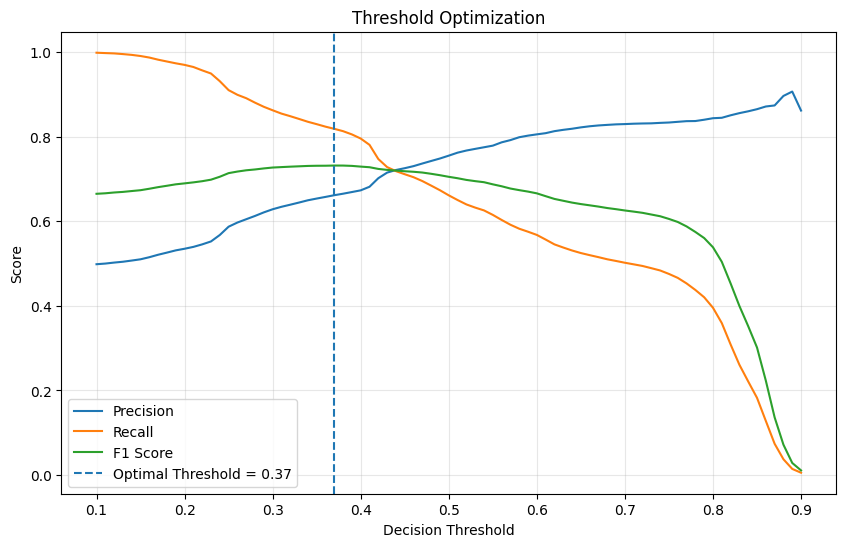

In [13]:
# ============================================================
# 12. THRESHOLD PERFORMANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    label="F1 Score"
)

plt.axvline(
    OPTIMAL_THRESHOLD,
    linestyle="--",
    label=f"Optimal Threshold = {OPTIMAL_THRESHOLD:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# completed 
**Hyperparameter Optimization → Best Model → OOF Probability → Optimal Threshold**

# Final Model Retraining

In [14]:
# ============================================================
# 13. FINAL MODEL RETRAINING
# ============================================================

# Retrain the selected optimized model on the complete
# training dataset.

final_model = best_search.best_estimator_

final_model.fit(
    X_train,
    y_train
)

print("Final optimized model retrained successfully.")
print("Final Model:", best_model_name)

Final optimized model retrained successfully.
Final Model: XGBoost


# Untouched Test-Set Evaluation

In [15]:
# ============================================================
# 14. FINAL TEST-SET EVALUATION
# ============================================================

# Generate probability scores on the completely untouched
# test dataset.

test_probabilities = final_model.predict_proba(
    X_test
)[:, 1]


# Apply the optimized threshold
test_predictions = (
    test_probabilities >= OPTIMAL_THRESHOLD
).astype(int)


# ------------------------------------------------------------
# Calculate final metrics
# ------------------------------------------------------------

final_accuracy = accuracy_score(
    y_test,
    test_predictions
)

final_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)


# ------------------------------------------------------------
# Display final results
# ------------------------------------------------------------

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

final_metrics["Score"] = final_metrics["Score"].round(4)

display(final_metrics)

print("\n✓ Final evaluation completed on untouched test set.")

,Metric,Score
0,Accuracy,0.6990
1,Precision,0.6573
2,Recall,0.8163
3,F1 Score,0.7282
4,ROC-AUC,0.7884



✓ Final evaluation completed on untouched test set.


# Confusion Matrix + Classification Report

Classification Report:

                           precision    recall  f1-score   support

No Cardiovascular Disease       0.77      0.58      0.66      6326
   Cardiovascular Disease       0.66      0.82      0.73      6174

                 accuracy                           0.70     12500
                macro avg       0.71      0.70      0.70     12500
             weighted avg       0.71      0.70      0.70     12500



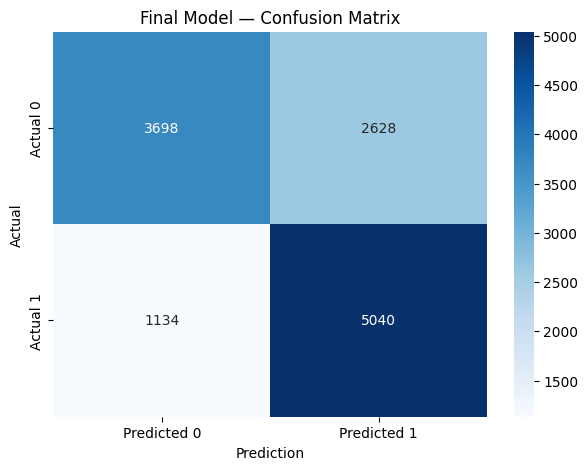

In [16]:
# ============================================================
# 15. CONFUSION MATRIX & CLASSIFICATION REPORT
# ============================================================

print("Classification Report:\n")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "No Cardiovascular Disease",
            "Cardiovascular Disease"
        ],
        zero_division=0
    )
)


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted 0",
        "Predicted 1"
    ],
    yticklabels=[
        "Actual 0",
        "Actual 1"
    ]
)

plt.title("Final Model — Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")

plt.show()

# ROC Curve

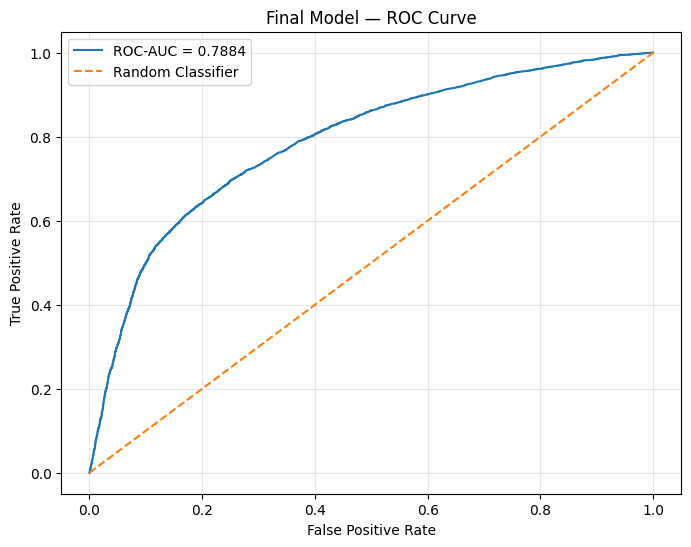

In [17]:
# ============================================================
# 16. ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(
    y_test,
    test_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {final_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Final Model — ROC Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Final Model Summary

In [18]:
# ============================================================
# 17. FINAL MODEL SUMMARY
# ============================================================

print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print(f"\nSelected Model      : {best_model_name}")
print(f"Optimal Threshold   : {OPTIMAL_THRESHOLD:.2f}")
print(f"Test Accuracy       : {final_accuracy:.4f}")
print(f"Test Precision      : {final_precision:.4f}")
print(f"Test Recall         : {final_recall:.4f}")
print(f"Test F1 Score       : {final_f1:.4f}")
print(f"Test ROC-AUC        : {final_roc_auc:.4f}")

print("\n Final optimized cardiovascular risk model completed.")

FINAL MODEL SUMMARY

Selected Model      : XGBoost
Optimal Threshold   : 0.37
Test Accuracy       : 0.6990
Test Precision      : 0.6573
Test Recall         : 0.8163
Test F1 Score       : 0.7282
Test ROC-AUC        : 0.7884

 Final optimized cardiovascular risk model completed.


# Save Final Model Artifact

## What is a Model Artifact?

Think of the trained model as a **calculator** that learned to predict cardiovascular risk.

**Patient Data → Training → Trained Model → Save**

We save it as `final_cardiovascular_risk_model.joblib` so it can be reused for new patients **without retraining**.

> **Model Artifact = A trained ML model saved as a reusable file.**

In [19]:
# ============================================================
# 18. SAVE FINAL MODEL ARTIFACT
# ============================================================

import os
import json
import joblib

ARTIFACT_DIR = "/kaggle/working/cardiovascular_risk_model"

os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Save trained model
MODEL_PATH = os.path.join(
    ARTIFACT_DIR,
    "final_cardiovascular_risk_model.joblib"
)

joblib.dump(final_model, MODEL_PATH)


# Save optimized threshold
THRESHOLD_PATH = os.path.join(
    ARTIFACT_DIR,
    "optimized_threshold.json"
)

with open(THRESHOLD_PATH, "w") as f:
    json.dump(
        {
            "optimal_threshold": OPTIMAL_THRESHOLD
        },
        f,
        indent=4
    )


# Save feature names
FEATURE_PATH = os.path.join(
    ARTIFACT_DIR,
    "feature_names.json"
)

with open(FEATURE_PATH, "w") as f:
    json.dump(
        list(X_train.columns),
        f,
        indent=4
    )


print(" Final model saved:")
print(MODEL_PATH)

print("\n Threshold saved:")
print(THRESHOLD_PATH)

print("\n Feature names saved:")
print(FEATURE_PATH)

 Final model saved:
/kaggle/working/cardiovascular_risk_model/final_cardiovascular_risk_model.joblib

 Threshold saved:
/kaggle/working/cardiovascular_risk_model/optimized_threshold.json

 Feature names saved:
/kaggle/working/cardiovascular_risk_model/feature_names.json


# Load Saved Artifacts
**So  now next  these  saved artifacts ,loading and  making these  reusable predict_risk() function . this is  Notebook3  deployment-ready part .**

In [20]:
# ============================================================
# 21. LOAD SAVED MODEL ARTIFACTS
# ============================================================

import joblib
import json

# Paths of saved artifacts
MODEL_PATH = "/kaggle/working/cardiovascular_risk_model/final_cardiovascular_risk_model.joblib"
THRESHOLD_PATH = "/kaggle/working/cardiovascular_risk_model/optimized_threshold.json"
FEATURE_PATH = "/kaggle/working/cardiovascular_risk_model/feature_names.json"


# Load trained model
loaded_model = joblib.load(MODEL_PATH)


# Load optimized threshold
with open(THRESHOLD_PATH, "r") as f:
    threshold_data = json.load(f)

loaded_threshold = threshold_data["optimal_threshold"]


# Load feature names
with open(FEATURE_PATH, "r") as f:
    loaded_features = json.load(f)


print(" Model artifact loaded")
print(" Optimized threshold loaded")
print(" Feature names loaded")

print("\nLoaded threshold:", loaded_threshold)

print("\nRequired features:")
for feature in loaded_features:
    print("-", feature)

 Model artifact loaded
 Optimized threshold loaded
 Feature names loaded

Loaded threshold: 0.3699999999999999

Required features:
- gender
- height
- weight
- ap_hi
- ap_lo
- cholesterol
- gluc
- smoke
- alco
- active
- age_years
- BMI


# Verify Loaded Artifact

In [21]:
# ============================================================
# 22. VERIFY LOADED ARTIFACT
# ============================================================

print("Original threshold :", OPTIMAL_THRESHOLD)
print("Loaded threshold   :", loaded_threshold)

print(
    "\nFeature count:",
    len(loaded_features)
)

print(
    "Training feature count:",
    len(X_train.columns)
)


# Verify that saved features match training features
assert loaded_features == list(X_train.columns), \
    "Saved features do not match training features!"

print("\n Saved artifacts verified successfully.")

Original threshold : 0.3699999999999999
Loaded threshold   : 0.3699999999999999

Feature count: 12
Training feature count: 12

 Saved artifacts verified successfully.


# Reusable Prediction Function

**Patient Data
     ↓
Preprocessing
     ↓
Saved Model
     ↓
Probability
     ↓
Saved Threshold
     ↓
Risk Result**

In [22]:
# ============================================================
# 23. REUSABLE PREDICTION FUNCTION
# ============================================================

def predict_risk(patient_data):
    """
    Predict cardiovascular disease risk for a new patient.

    Parameters
    ----------
    patient_data : dict
        Patient information containing all required model features.

    Returns
    -------
    dict
        Risk probability, threshold and final prediction.
    """

    # Convert input dictionary into DataFrame
    patient_df = pd.DataFrame(
        [patient_data]
    )


    # Ensure required features are present
    missing_features = [
        feature
        for feature in loaded_features
        if feature not in patient_df.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing required features: {missing_features}"
        )


    # Keep features in exactly the same order
    patient_df = patient_df[
        loaded_features
    ]


    # Generate risk probability
    risk_probability = loaded_model.predict_proba(
        patient_df
    )[0][1]


    # Apply optimized threshold
    prediction = int(
        risk_probability >= loaded_threshold
    )


    # Human-readable result
    risk_label = (
        "High Risk"
        if prediction == 1
        else "Low Risk"
    )


    return {
        "risk_probability": round(
            float(risk_probability), 4
        ),
        "threshold": round(
            float(loaded_threshold), 4
        ),
        "prediction": prediction,
        "risk_label": risk_label
    }


print(" Reusable prediction function created.")

 Reusable prediction function created.


#  Pipeline testing by a real patient data
**Patient → Prediction Function → Probability → Threshold → High/Low Risk**

**New Patient
     ↓
Raw Patient Input
     ↓
Same Preprocessing
     ↓
Model-Ready Features
     ↓
Load Saved Model
     ↓
predict_proba()
     ↓
Probability
     ↓
Optimized Threshold
     ↓
Risk / No Risk**


**for example -: Patient
age = 52
height = 170
weight = 82
BP = 145/90
...
        ↓
Feature Engineering
        ↓
BMI = 28.37
age_years = 52
        ↓
Saved XGBoost
        ↓
Probability = 0.62
        ↓
0.62 ≥ 0.37
        ↓
CVD RISK**

CARDIOVASCULAR RISK PREDICTION

Risk Probability : 40.47%
Decision Threshold: 37.00%
Prediction        : 1
Risk Level        : High Risk


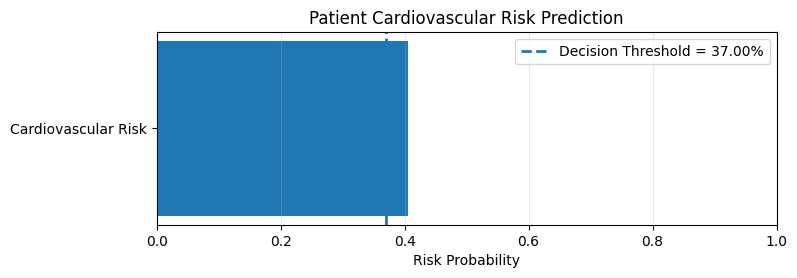

In [23]:
# ============================================================
# 24. TEST THE REUSABLE PREDICTION FUNCTION
# ============================================================

# Example patient input
# Values must follow the same feature definitions
# used during Notebook 2 preparation.

sample_patient = {
    "gender": 2,
    "height": 170,
    "weight": 70,
    "ap_hi": 120,
    "ap_lo": 80,
    "cholesterol": 1,
    "gluc": 1,
    "smoke": 0,
    "alco": 0,
    "active": 1,
    "age_years": 40,
    "BMI": 24.22
}


# Generate prediction
result = predict_risk(sample_patient)


# Display result
print("=" * 50)
print("CARDIOVASCULAR RISK PREDICTION")
print("=" * 50)

print(
    f"\nRisk Probability : "
    f"{result['risk_probability']:.2%}"
)

print(
    f"Decision Threshold: "
    f"{result['threshold']:.2%}"
)

print(
    f"Prediction        : "
    f"{result['prediction']}"
)

print(
    f"Risk Level        : "
    f"{result['risk_label']}"
)






# RISK PROBABILITY VISUALIZATION


import matplotlib.pyplot as plt

risk_probability = result["risk_probability"]
threshold = result["threshold"]

plt.figure(figsize=(8, 2.5))

plt.barh(
    ["Cardiovascular Risk"],
    [risk_probability],
    height=0.35
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label=f"Decision Threshold = {threshold:.2%}"
)

plt.xlim(0, 1)
plt.xlabel("Risk Probability")
plt.title("Patient Cardiovascular Risk Prediction")

plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.show()

# Verify End-to-End Prediction

In [26]:
# ============================================================
# 25. END-TO-END PIPELINE VERIFICATION
# ============================================================

print("Checking complete prediction pipeline...\n")

# Verify prediction output contains all expected fields
required_outputs = [
    "risk_probability",
    "threshold",
    "prediction",
    "risk_label"
]

for output in required_outputs:
    assert output in result, \
        f"Missing prediction output: {output}"


# Verify probability is valid
assert 0 <= result["risk_probability"] <= 1

# Verify prediction is binary
assert result["prediction"] in [0, 1]

# Verify risk label
assert result["risk_label"] in [
    "Low Risk",
    "High Risk"
]


print(" Model loaded successfully")
print(" Patient input accepted")
print(" Risk probability generated")
print(" Optimized threshold applied")
print(" Final risk prediction generated")

print("\n END-TO-END PREDICTION PIPELINE VERIFIED")

Checking complete prediction pipeline...

 Model loaded successfully
 Patient input accepted
 Risk probability generated
 Optimized threshold applied
 Final risk prediction generated

 END-TO-END PREDICTION PIPELINE VERIFIED


#  Notebook 3  ---> core + deployment pipeline successfully completed !

# API Contract  started 








## Prediction API Contract

### Input

The prediction system accepts the following patient features:

- gender
- height
- weight
- ap_hi
- ap_lo
- cholesterol
- gluc
- smoke
- alco
- active
- age_years
- BMI

### Prediction Flow

**Patient Input**
        ↓
**Saved Optimized Model**
        ↓
**Risk Probability**
        ↓
**Optimized Decision Threshold**
        ↓
**Final Risk Prediction**

### Output

The prediction function returns:

- `risk_probability` → predicted cardiovascular disease probability
- `threshold` → optimized decision threshold
- `prediction` → 0 (Low Risk) or 1 (High Risk)
- `risk_label` → Low Risk / High Risk

### Example Output

```text
{
    "risk_probability": 0.68,
    "threshold": 0.50,
    "prediction": 1,
    "risk_label": "High Risk"
}



This contract makes the trained model ready for integration
with a future API, web application, or frontend.

**FastAPI app created
        ↓
PatientInput schema
        ↓
POST /predict endpoint
        ↓
predict_risk()
        ↓
JSON result**

In [27]:
# ============================================================
# 27. PREDICTION API
# ============================================================

from fastapi import FastAPI
from pydantic import BaseModel


# ------------------------------------------------------------
# Create FastAPI application
# ------------------------------------------------------------

app = FastAPI(
    title="Cardiovascular Disease Risk Prediction API",
    description="API for predicting cardiovascular disease risk.",
    version="1.0.0"
)


# ------------------------------------------------------------
# Define input schema
# ------------------------------------------------------------

class PatientInput(BaseModel):

    gender: int
    height: float
    weight: float
    ap_hi: float
    ap_lo: float
    cholesterol: int
    gluc: int
    smoke: int
    alco: int
    active: int
    age_years: float
    BMI: float


# ------------------------------------------------------------
# Prediction endpoint
# ------------------------------------------------------------

@app.post("/predict")
def predict(patient: PatientInput):

    patient_data = patient.model_dump()

    result = predict_risk(patient_data)

    return result


# ------------------------------------------------------------
# Health check endpoint
# ------------------------------------------------------------

@app.get("/")
def health_check():

    return {
        "status": "API is running",
        "model": best_model_name,
        "threshold": loaded_threshold
    }


print(" FastAPI application created successfully.")
print(" POST /predict endpoint created.")
print(" GET / health-check endpoint created.")
print(" API code/endpoint created: ✅.")



 FastAPI application created successfully.
 POST /predict endpoint created.
 GET / health-check endpoint created.
 API code/endpoint created: ✅.


# ============================================================
# 27. FINAL NOTEBOOK SUMMARY
# ============================================================

## Final ML Pipeline — Cardiovascular Disease Risk Prediction

### Previous Notebooks

**Notebook 1**
→ Outlier Removal + Data Cleaning

**Notebook 2**
→ Feature Engineering + Data Preparation
→ Stratified Train/Test Split
→ Baseline Models

### Notebook 3 — Model Optimization & Deployment

**Processed Data**
        ↓
**Hyperparameter Optimization**
        ↓
**Optimized Model Comparison**
        ↓
**Best Model Selection**
        ↓
**Out-of-Fold Probability**
        ↓
**Decision Threshold Optimization**
        ↓
**Final Model Retraining**
        ↓
**Untouched Test Evaluation**
        ↓
**Final Metrics**
        ↓
**Model Artifact Saving**
        ↓
**Reusable Prediction Function**
        ↓
**API Contract**
        ↓
**End-to-End Verification**

### Final Deliverables

- Optimized ML model
- Optimized decision threshold
- Final evaluation metrics
- Saved model artifact
- Reusable prediction function
- Prediction API contract
- Verified end-to-end prediction pipeline

### Final Goal

A reproducible and deployment-ready cardiovascular disease
risk prediction system that can accept patient information
and return a risk probability and final risk prediction.